##Sanaz

# Searching for the category

In [3]:
from google.colab import files
uploaded = files.upload()


Saving brands_qu.csv to brands_qu.csv
Saving orderlines_qu.csv to orderlines_qu (1).csv
Saving orders_qu.csv to orders_qu (1).csv
Saving products_qu.csv to products_qu (1).csv
Saving products_with_category.csv to products_with_category (1).csv


In [4]:
import pandas as pd

# Orders table (includes order date)
orders_qu = pd.read_csv("orders_qu.csv", parse_dates=["created_date"])

# Orderlines table (items sold)
orderlines_qu = pd.read_csv("orderlines_qu.csv")

# Brands table (SKU -> brand)
brands_qu = pd.read_csv("brands_qu.csv")

# Products table WITH your final category column
products_cat = pd.read_csv("products_with_category.csv")

## Step 1

In [6]:
# Merge orderlines with products (price + category)
df = orderlines_qu.merge(
    products_cat[["sku", "price", "category"]],
    on="sku",
    how="left"
)

# Merge with orders to get the date
df = df.merge(
    orders_qu[["order_id", "created_date"]],
    left_on="id_order",
    right_on="order_id",
    how="left"
)


## Step 2:

This code builds the final analysis table used for studying discounts and revenue. First, it merges the orderlines data with the products table to bring in the product’s original price and category, and then merges with the orders table to add the order date. Next, it converts important columns (unit price, original price, and quantity) into numeric values to ensure calculations work correctly. After that, it calculates the discount percentage by comparing the selling price to the original price, and computes the revenue for each order line. Finally, it creates a month column from the order date so sales and discounts can be analyzed over time.

In [7]:
# Convert columns to numeric
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["product_quantity"] = pd.to_numeric(df["product_quantity"], errors="coerce")

# Create discount percentage
df["discount_%"] = (df["price"] - df["unit_price"]) / df["price"] * 100

# Create revenue column
df["revenue"] = df["unit_price"] * df["product_quantity"]

# Create month column for time analysis
df["month"] = df["created_date"].dt.to_period("M").astype(str)


## total revenue per month per each category


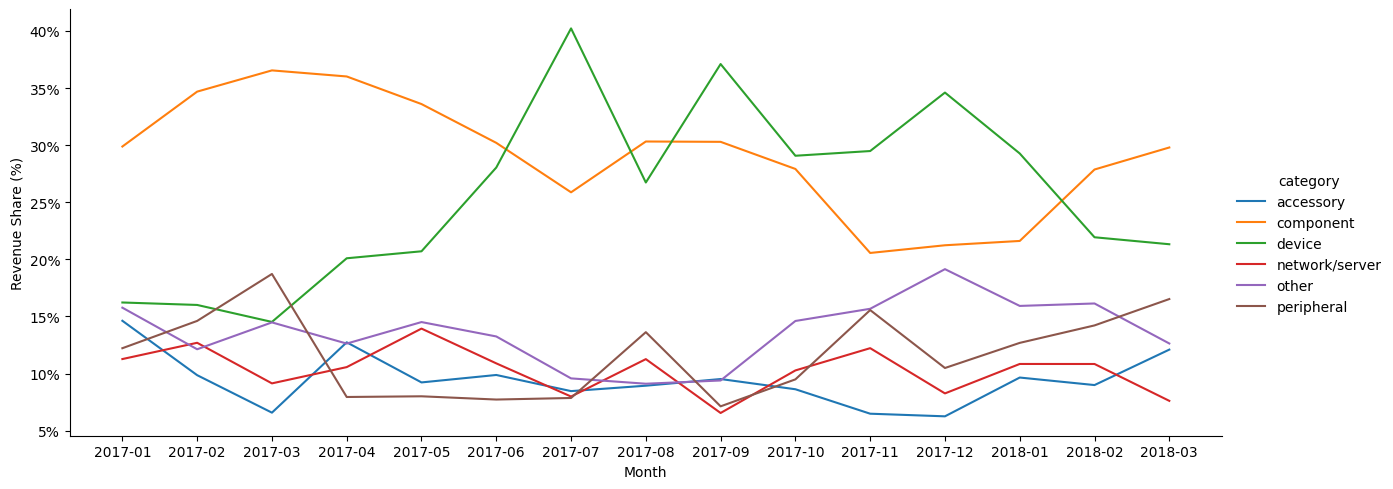

In [11]:
import seaborn as sns

# Sum revenue per month & category
monthly_cat_rev = (
    df.groupby(["month", "category"], as_index=False)["revenue"]
      .sum()
)

# Calculate total revenue per month
monthly_cat_rev["total_month"] = (
    monthly_cat_rev.groupby("month")["revenue"]
    .transform("sum")
)

# Percentage share
monthly_cat_rev["revenue_pct"] = (
    monthly_cat_rev["revenue"] / monthly_cat_rev["total_month"]
)


g = sns.relplot(
    kind="line",
    data=monthly_cat_rev,
    x="month",
    y="revenue_pct",
    hue="category",
    height=5,
    aspect=2.5
)

g.set_axis_labels("Month", "Revenue Share (%)")

# Convert axis to percent format
g.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")



## total revenue per month per each category per discount

/tmp/ipython-input-1999044625.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["month", "category", "discount_group"], as_index=False)["revenue"]


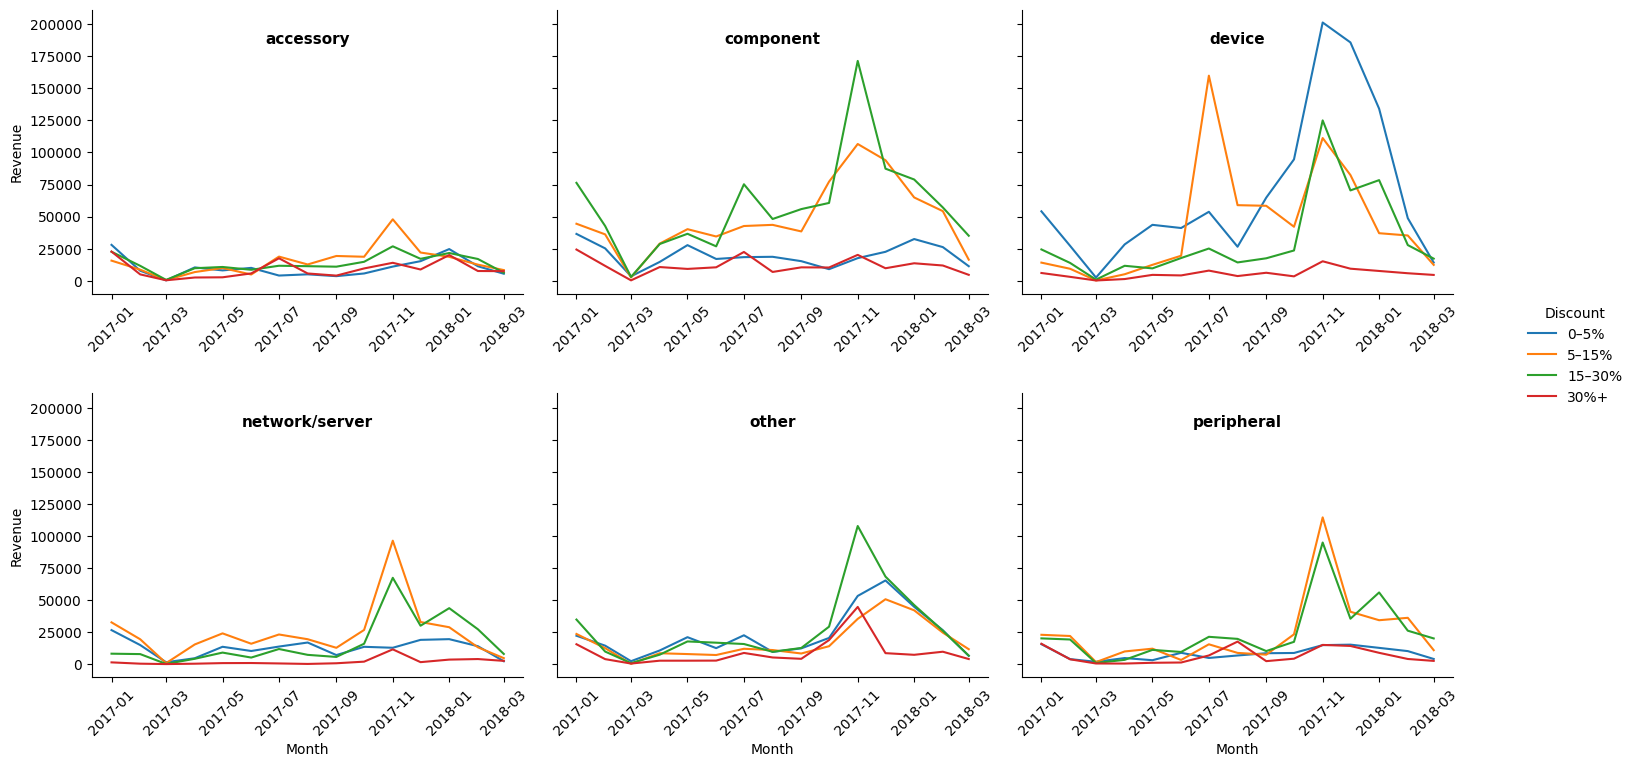

In [12]:
import pandas as pd
import seaborn as sns

# --- Ensure required columns exist ---
df = df.copy()

# Month as real datetime (for clean x-axis)
df["month"] = pd.to_datetime(df["created_date"]).dt.to_period("M").dt.to_timestamp()

# Discount % and groups (if not already created)
df["discount_%"] = (df["price"] - df["unit_price"]) / df["price"] * 100
df["discount_group"] = pd.cut(
    df["discount_%"],
    bins=[-100, 5, 15, 30, 100],
    labels=["0–5%", "5–15%", "15–30%", "30%+"]
)

# --- Aggregate: revenue per month, per category, per discount group ---
monthly_rev = (
    df.groupby(["month", "category", "discount_group"], as_index=False)["revenue"]
      .sum()
)

# --- Plot ---
g = sns.relplot(
    data=monthly_rev,
    kind="line",
    x="month",
    y="revenue",
    hue="discount_group",
    col="category",
    col_wrap=3,
    height=3.8,
    aspect=1.3
)

# Titles and labels
g.set_titles("")
g.set_axis_labels("Month", "Revenue")

for ax, cat in zip(g.axes.flat, monthly_rev["category"].unique()):
    ax.text(
        0.5, 0.88, cat,           # position inside plot
        transform=ax.transAxes,
        ha="center",
        fontsize=11,
        weight="bold"
    )

# Axis labels
g.set_axis_labels("Month", "Revenue")


    # Force x tick labels to show on ALL subplots
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelbottom=True, rotation=45)


# Proper legend placement
sns.move_legend(
    g, "center right",
    bbox_to_anchor=(1.03, 0.5),
    title="Discount"
)

g.fig.subplots_adjust(hspace=0.35)

## discount percentage vs revenue  vs categories?:





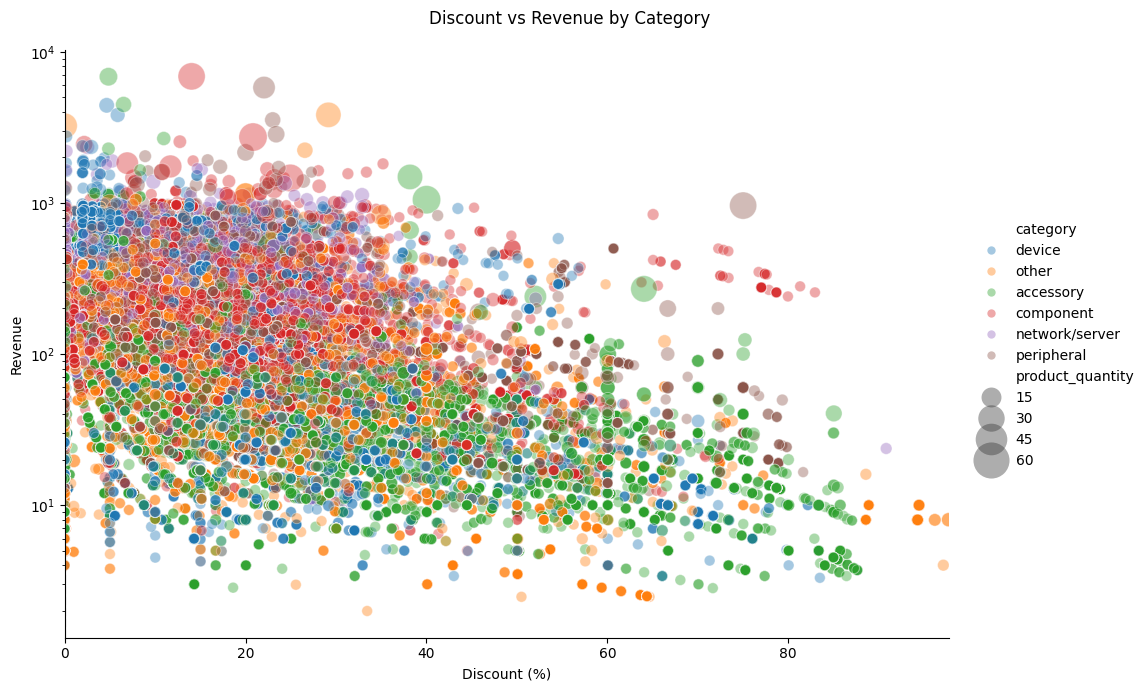

In [13]:
g = sns.relplot(
    data=df,
    x="discount_%",
    y="revenue",
    hue="category",
    size="product_quantity",
    sizes=(60, 800),

    alpha=0.4,
    height=7,
    aspect=1.4
)

g.fig.suptitle("Discount vs Revenue by Category")

g.set_axis_labels("Discount (%)", "Revenue")

g.set(yscale="log")

g.refline(x=0, linestyle="--")

g.set(xlim=(0, df["discount_%"].max()))

g.tight_layout()



In [14]:
# Create a copy to check price behavior
df_check = df.copy()

# Define price relation
df_check["price_relation"] = "Equal"

df_check.loc[df_check["unit_price"] < df_check["price"], "price_relation"] = "Discount"
df_check.loc[df_check["unit_price"] > df_check["price"], "price_relation"] = "Markup"


df_check.groupby("price_relation").head(5)[
    ["product_id", "price", "unit_price", "discount_%", "price_relation"]
]


,product_id,price,unit_price,discount_%,price_relation
0,0,60.99,47.49,22.134776,Discount
1,0,22.95,18.99,17.254902,Discount
2,0,89.00,72.19,18.887640,Discount
3,0,76.99,60.90,20.898818,Discount
4,0,299.99,142.49,52.501750,Discount
45,0,337.00,398.99,-18.394659,Markup
56,0,249.99,275.49,-10.200408,Markup
76,0,174.99,176.69,-0.971484,Markup
83,0,549.00,549.00,0.000000,Equal
85,0,5.95,5.99,-0.672269,Markup


## Distribution of order lines across discount levels

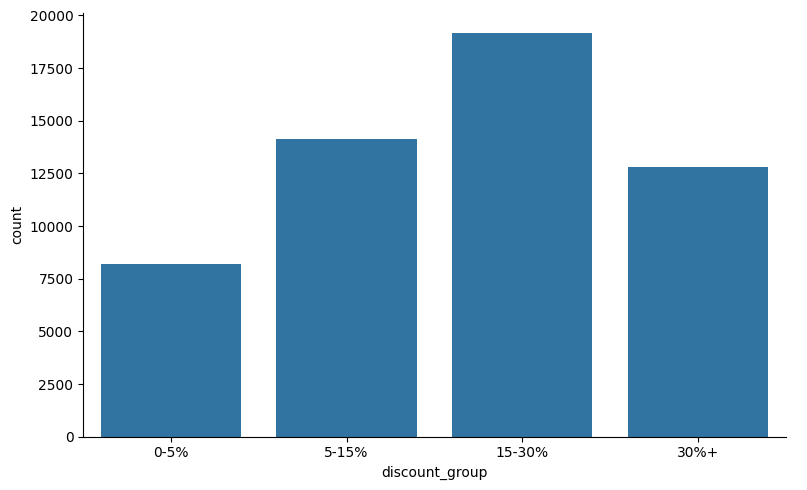

In [15]:
# Create discount percentage
df["discount_%"] = (df["price"] - df["unit_price"]) / df["price"] * 100

# Create discount groups (bins)
df["discount_group"] = pd.cut(
    df["discount_%"],
    bins=[-100, 5, 15, 30, 100],
    labels=["0-5%", "5-15%", "15-30%", "30%+"]
)

sns.catplot(
    data=df,
    kind="count",
    x="discount_group",
    height=5,
    aspect=1.6
)


Result:

This shows how many order lines there are in each discount group.
I can clearly see that most sales fall within the 5–15% and 15–30% discount ranges.

## Impact of Discounts on Monthly Revenue

/tmp/ipython-input-2844796452.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["month", "discount_group"], as_index=False)["revenue"]


Text(0.5, 1.03, 'Impact of Discounts on Monthly Revenue')

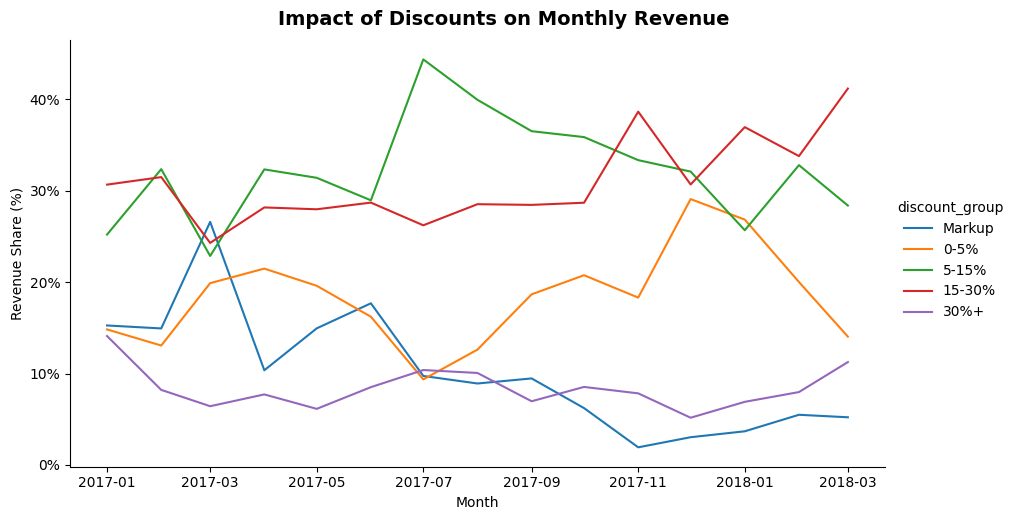

In [44]:
bf = (
    df.groupby(["month", "discount_group"], as_index=False)["revenue"]
      .sum()
)

# کل درآمد هر ماه
bf["total_month"] = (
    bf.groupby("month")["revenue"]
      .transform("sum")
)

# سهم درصدی
bf["revenue_pct"] = bf["revenue"] / bf["total_month"]


g = sns.relplot(
    data=bf,
    kind="line",
    x="month",
    y="revenue_pct",
    hue="discount_group",
    height=5,
    aspect=1.8
)

g.set_axis_labels("Month", "Revenue Share (%)")

# فرمت درصد روی محور Y
g.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")




g.fig.suptitle(
    "Impact of Discounts on Monthly Revenue",
    y=1.03,
    fontsize=14,
    fontweight="bold"
)


Result:

During Black Friday, discounts increased, but revenue did not grow proportionally

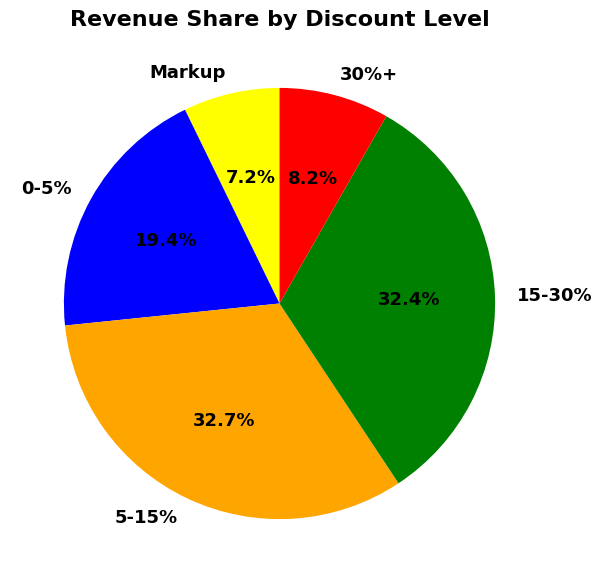

In [43]:
# Define custom colors for each discount group
color_map = {
    "Markup": "yellow",
    "0-5%": "blue",
    "5-15%": "orange",
    "15-30%": "green",
    "30%+": "red"
}

# Build color list in the same order as the pie slices
groups = rev_discount["discount_group"].astype(str)
colors = [color_map[g] for g in groups]


ax = rev_discount.set_index("discount_group")["revenue"].plot.pie(
    autopct="%1.1f%%",
    figsize=(7,7),
    ylabel="",
    startangle=90,
    colors=colors   #  IMPORTANT: apply the colors here

)

# Make the title bold and larger
ax.set_title(
    "Revenue Share by Discount Level",
    fontsize=16,
    fontweight="bold"
)

# All texts (group labels + percentages)
for t in ax.texts:
    t.set_fontsize(13)
    t.set_fontweight("bold")

# # Make percentage texts inside slices white
# n = len(rev_discount)
# autotexts = ax.texts[n:]

# for t in autotexts:
#     t.set_color("white")


/tmp/ipython-input-3120671638.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group", as_index=False)["revenue"]


<Axes: title={'center': 'Revenue Share by Discount Level'}>

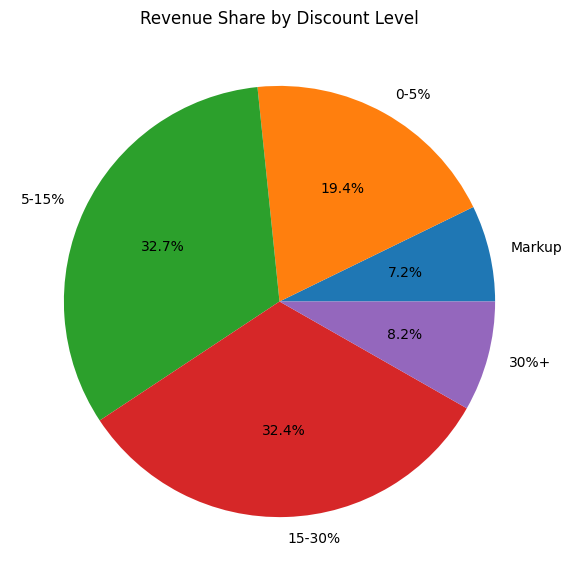

In [30]:
# Create discount groups
df["discount_group"] = pd.cut(
    df["discount_%"],
    bins=[-100, 0, 5, 15, 30, 100],
    labels=["Markup", "0-5%", "5-15%", "15-30%", "30%+"]
)


rev_discount = (
    df.groupby("discount_group", as_index=False)["revenue"]
      .sum()
)



rev_discount.set_index("discount_group")["revenue"].plot.pie(
    autopct="%1.1f%%",
    figsize=(7,7),
    ylabel="",
    title="Revenue Share by Discount Level"
)


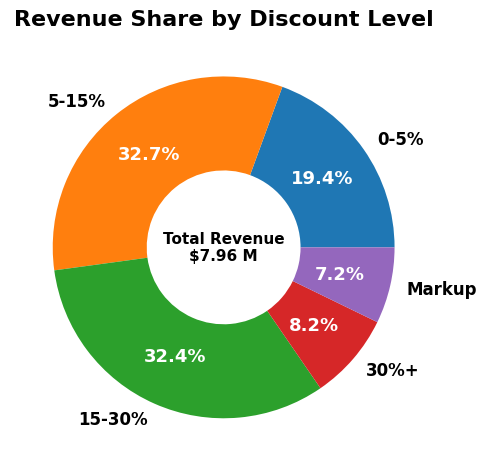

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
    'level': ['0-5%', '5-15%', '15-30%', '30%+', 'Markup'],
    'share': [19.4, 32.7, 32.4, 8.2, 7.2]
})

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

g = sns.relplot()          # فقط برای گرفتن figure
fig = g.figure

# ✅ این خط مهمه: محور پیش‌فرض seaborn رو حذف کن
g.ax.remove()

# حالا فقط یک Axes داریم
ax = fig.add_subplot(111)

wedges, texts, autotexts = ax.pie(
    df['share'],
    labels=df['level'],
    colors=palette,
    autopct='%1.1f%%',
    pctdistance=0.7,
    wedgeprops=dict(width=0.55)
)

for t in autotexts:
    t.set_fontsize(13)
    t.set_weight('bold')
    t.set_color('white')

    #  (labels)
for t in texts:
    t.set_weight('bold')
    t.set_fontsize(12)

ax.set_title('Revenue Share by Discount Level', fontsize=16, weight='bold')
ax.text(0, 0, 'Total Revenue\n$7.96 M',
        ha='center', va='center',
        fontsize=11, weight='bold')

ax.set_axis_off()   # ✅ اینجا هم برای اطمینان
fig.show()



In [ ]:
total_revenue = df["revenue"].sum()
total_revenue


np.float64(7965020.699999999)